# DS Lab 5: Logistic Regression
Social Network Ads Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, precision_score, recall_score

In [2]:
# dataset Social_Network_Ads
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
X = df[['Age','EstimatedSalary']]
y = df['Purchased']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [6]:
y_pred = model.predict(X_test)

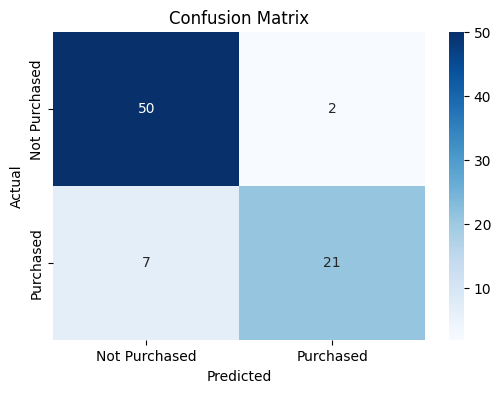

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Build confusion matrix before plotting
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Purchased', 'Purchased'],
            yticklabels=['Not Purchased', 'Purchased'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

error_rate = 1 - accuracy

print("Accuracy:", accuracy*100, "%")
print("Error Rate:", error_rate*100, "%")
print("Precision:", precision*100, "%")
print("Recall:", recall*100, "%")

Accuracy: 88.75 %
Error Rate: 11.250000000000004 %
Precision: 91.30434782608695 %
Recall: 75.0 %


In [7]:
def predict_and_visualize(row_number):
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    # Validate input
    if row_number < 0 or row_number >= len(X_test):
        print(f"Invalid row number! Please enter a number between 0 and {len(X_test)-1}")
        return
    # Get the specific row
    test_sample = X_test.iloc[row_number].values.reshape(1, -1)
    actual_result = y_test.iloc[row_number]
    
    # Make prediction
    predicted_result = model.predict(test_sample)[0]
    
    # Get prediction probability
    prediction_probability = model.predict_proba(test_sample)[0]
    
    # Display Results
    print("="*50)
    print(f"ROW NUMBER: {row_number}")
    print("="*50)
    print(f"Age: {X_test.iloc[row_number]['Age']}")
    print(f"Estimated Salary: ${X_test.iloc[row_number]['EstimatedSalary']:,.2f}")
    print("-"*50)
    print(f"Actual Result: {'Purchased' if actual_result == 1 else 'Not Purchased'}")
    print(f"Predicted Result: {'Purchased' if predicted_result == 1 else 'Not Purchased'}")
    print(f"Prediction Confidence: {max(prediction_probability)*100:.2f}%")
    print("-"*50)
    
    # Check if prediction is correct
    if actual_result == predicted_result:
        print("✓ PREDICTION IS CORRECT")
    else:
        print("✗ PREDICTION IS INCORRECT")
    print("="*50)
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot 1: Actual vs Predicted for this sample
    categories = ['Not Purchased', 'Purchased']
    predictions = [prediction_probability[0]*100, prediction_probability[1]*100]
    colors = ['#FF6B6B', '#4ECDC4']
    
    axes[0].bar(categories, predictions, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    axes[0].set_ylabel('Probability (%)', fontsize=12, fontweight='bold')
    axes[0].set_title(f'Prediction Probabilities\n(Row {row_number})', fontsize=12, fontweight='bold')
    axes[0].set_ylim([0, 100])
    axes[0].grid(axis='y', alpha=0.3)
    
    # Add percentage labels on bars
    for i, v in enumerate(predictions):
        axes[0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')
    
    # Plot 2: Confusion Matrix with this specific prediction highlighted
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Purchased', 'Purchased'],
                yticklabels=['Not Purchased', 'Purchased'],
                ax=axes[1], cbar=False)
    axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Actual', fontsize=12, fontweight='bold')
    axes[1].set_title('Overall Confusion Matrix\n(Model Performance)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Example usage:
# predict_and_visualize(0)  # Predict for row 0
# predict_and_visualize(50) # Predict for row 50

c:\Users\Admin\Desktop\DS\DS\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\Admin\Desktop\DS\DS\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


ROW NUMBER: 1
Age: 59
Estimated Salary: $88,000.00
--------------------------------------------------
Actual Result: Purchased
Predicted Result: Purchased
Prediction Confidence: 98.17%
--------------------------------------------------
✓ PREDICTION IS CORRECT


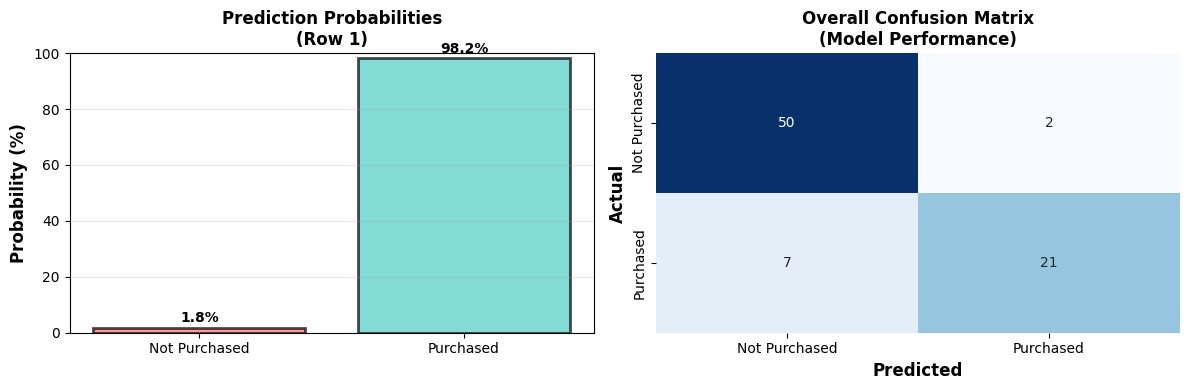

In [ ]:
# Test the function - Enter any row number between 0 and 99
# Try different row numbers to test different predictions
predict_and_visualize(0)   # Change this number to test different rows (0-99)